In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [2]:
spark = (SparkSession.builder.appName("EDA")
             .config("spark.driver.memory","16g")
             .config("spark.sql.shuffle.partitions","200")
             .config("spark.sql.adaptive.enabled","true")
             .getOrCreate())

In [3]:
panel = spark.read.parquet("D:/HSE/Diplom/processed_data/panel").cache()

In [4]:
abt = spark.read.parquet("D:/HSE/Diplom/processed_data/abt").cache()

Всего записей

In [5]:
panel.count()

82244050

In [6]:
panel.printSchema()

root
 |-- reference_pool_id: string (nullable = true)
 |-- loan_id: string (nullable = true)
 |-- monthly_reporting_period: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- orig_interest_rate: double (nullable = true)
 |-- current_interest_rate: double (nullable = true)
 |-- orig_upb: double (nullable = true)
 |-- current_actual_upb: double (nullable = true)
 |-- orig_loan_term: integer (nullable = true)
 |-- origination_date: string (nullable = true)
 |-- first_payment_date: string (nullable = true)
 |-- loan_age: integer (nullable = true)
 |-- remaining_months_legal_mat: integer (nullable = true)
 |-- remaining_months_to_mat: integer (nullable = true)
 |-- maturity_date: string (nullable = true)
 |-- orig_ltv: float (nullable = true)
 |-- orig_cltv: float (nullable = true)
 |-- num_borrowers: integer (nullable = true)
 |-- dti: float (nullable = true)
 |-- borrower_credit_score_orig: integer (nullable = true)
 |-- coborrower_credit_score_orig: integer (nullable = 

Уникальных кредитов

In [7]:
abt.count()

1293420

## Distribution of main classes

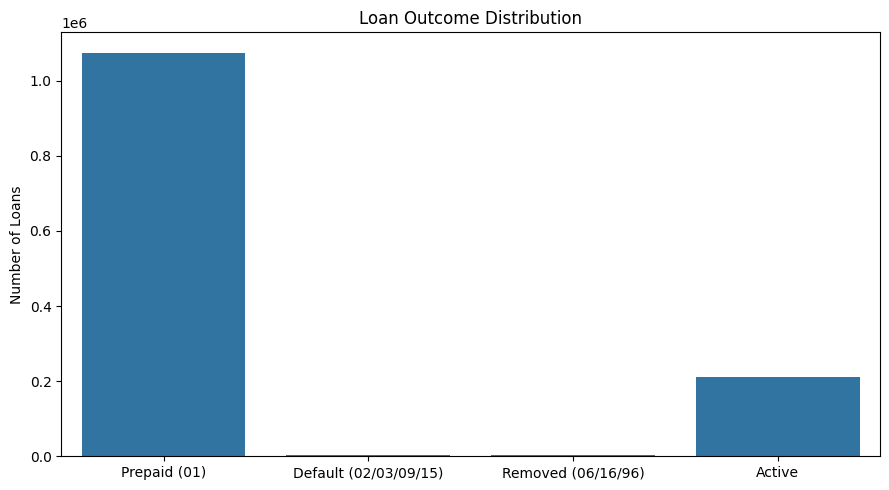

In [8]:
c = (
    abt.agg(
        F.sum("prepaid").alias("Prepaid (01)"),
        F.sum("default").alias("Default (02/03/09/15)"),
        F.sum("removed").alias("Removed (06/16/96)"),
        F.sum("active").alias("Active"),
    )
    .toPandas()
    .melt(var_name="Outcome", value_name="Count")
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=c,
    x="Outcome",
    y="Count"
)

ax.set_title("Loan Outcome Distribution")
ax.set_ylabel("Number of Loans")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

## Univariate Distributions

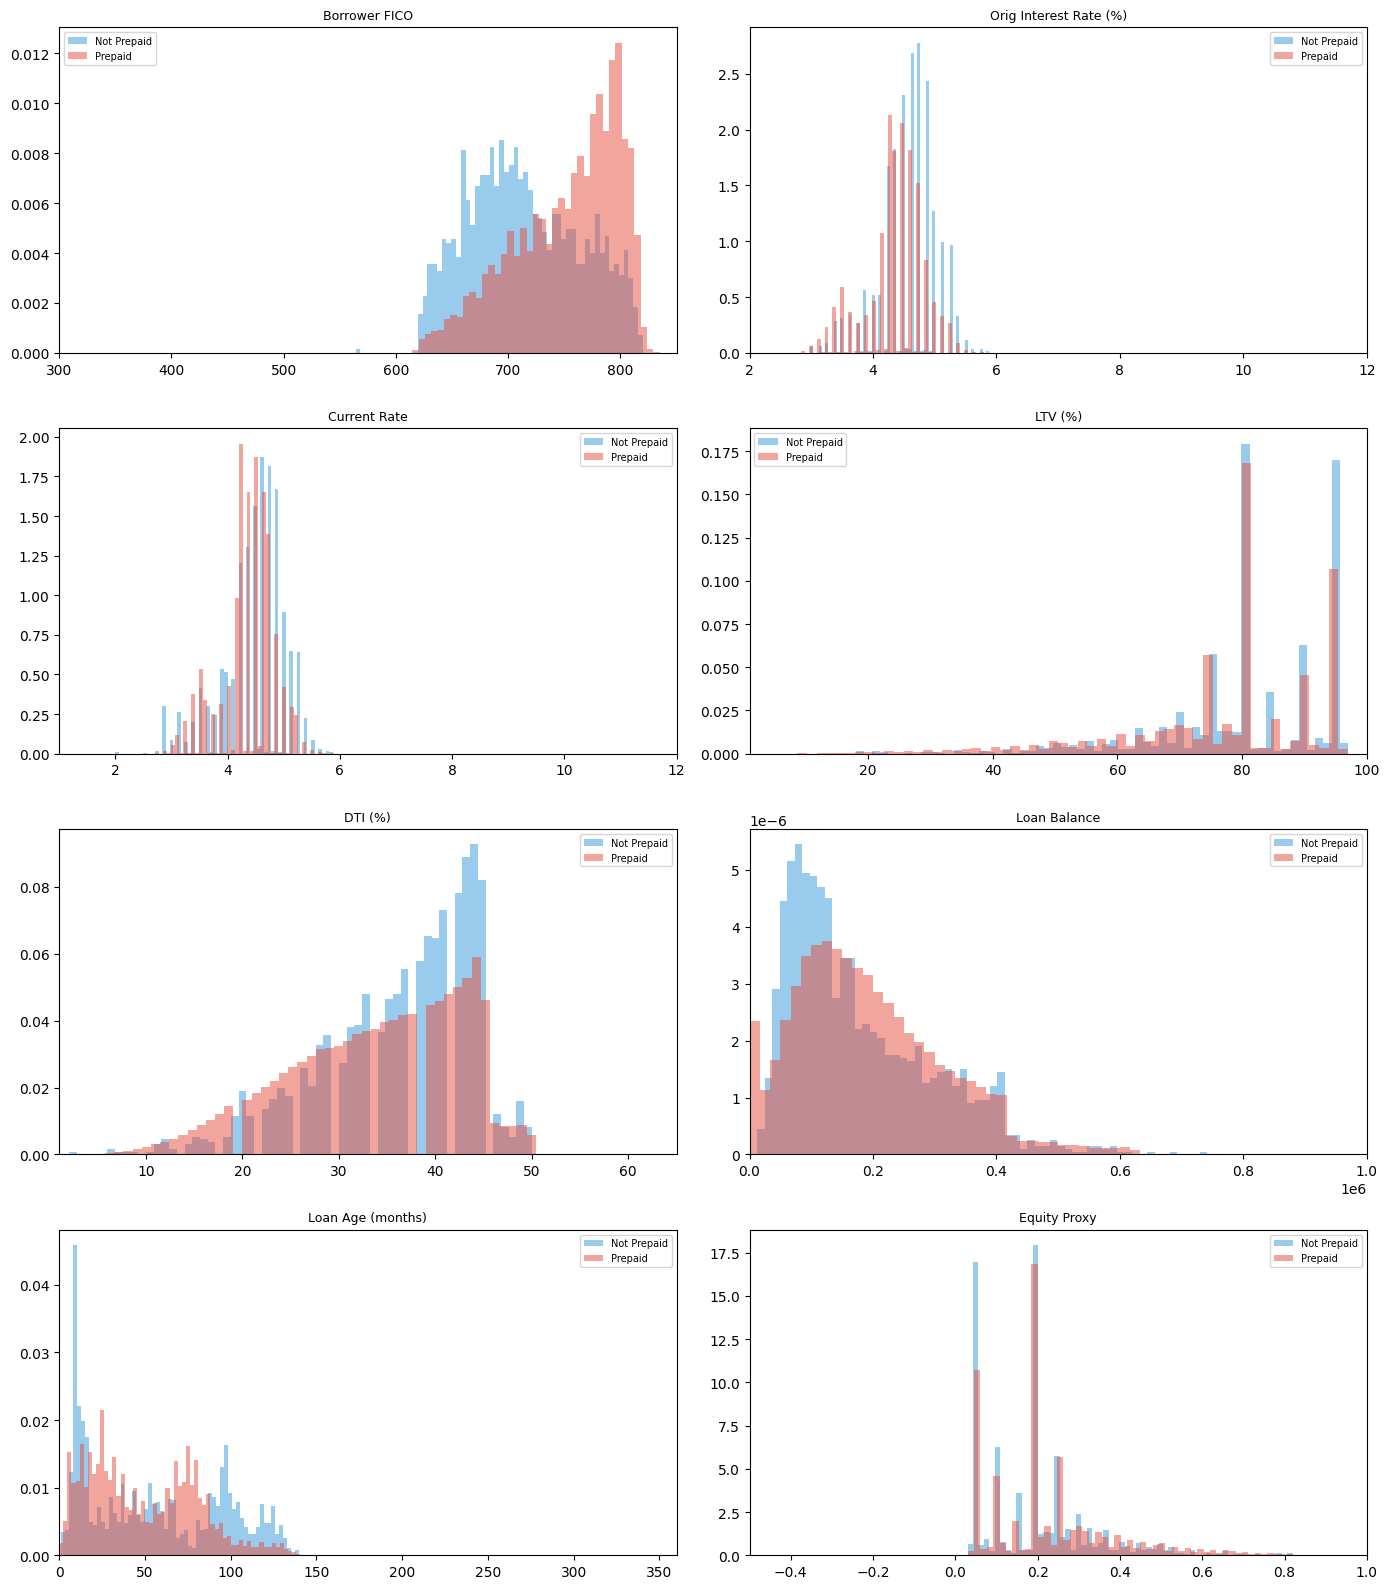

In [9]:
NUMERIC_COLS = [
    ("fico", "Borrower FICO", 300, 850),
    ("orig_interest_rate", "Orig Interest Rate (%)", 2.0, 12.0),
    ("current_interest_rate","Current Rate", 1.0, 12.0),
    ("orig_ltv", "LTV (%)", 1, 100),
    ("dti", "DTI (%)", 1, 65),
    ("current_actual_upb", "Loan Balance", 0, 1_000_000),
    ("loan_age", "Loan Age (months)", 0, 360),
    ("equity_proxy", "Equity Proxy", -0.5, 1),
    
]

frac = 0.2

cols = [c for c, *_ in NUMERIC_COLS if c in abt.columns]
pdf = (
    abt.select(cols + ["prepaid"])
       .sample(fraction=frac, seed=42)
       .toPandas()
)

nr = (len(NUMERIC_COLS) + 1) // 2
fig, axes = plt.subplots(nr, 2, figsize=(14, 4 * nr))
axes = axes.flatten()

for i, (col, label, xmin, xmax) in enumerate(NUMERIC_COLS):
    if col not in pdf.columns:
        axes[i].set_visible(False)
        continue

    ax = axes[i]

    for prepaid_value, color, legend_label in [
        (0, "#3498db", "Not Prepaid"),
        (1, "#e74c3c", "Prepaid"),
    ]:
        d = (
            pdf.loc[pdf["prepaid"] == prepaid_value, col]
               .dropna()
               .clip(xmin, xmax)
        )

        ax.hist(
            d,
            bins=60,
            alpha=0.5,
            color=color,
            label=legend_label,
            density=True
        )

    ax.set_title(label, fontsize=9)
    ax.set_xlim(xmin, xmax)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

## Bivariate distributions

,fico_bucket,n,n_pre,rate_pct
3,SubPrime,108,80,74.07
2,NearPrime,121725,96740,79.47
1,Prime,339666,281278,82.81
0,SuperPrime,831921,696945,83.78


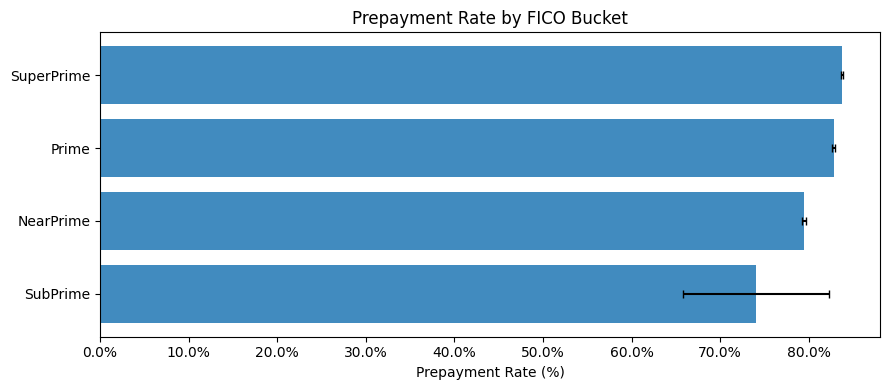

,loan_purpose,n,n_pre,rate_pct
3,U,2,1,50.00
1,C,250948,201134,80.15
2,R,246475,203568,82.59
0,P,795995,670340,84.21


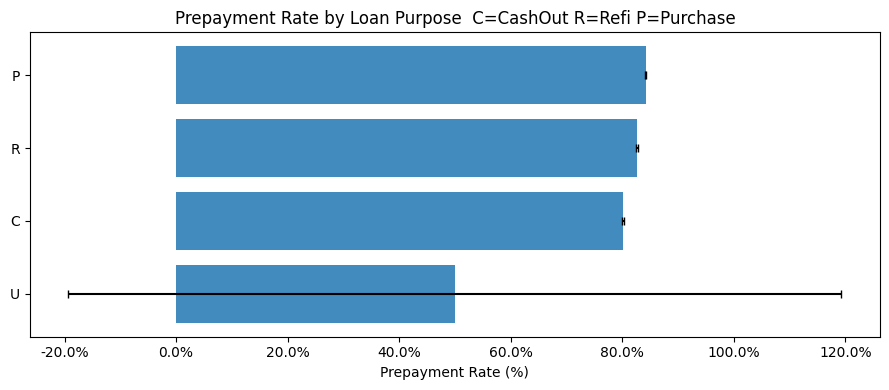

,channel,n,n_pre,rate_pct
0,R,748124,615579,82.28
1,C,410581,345001,84.03
2,B,134715,114463,84.97


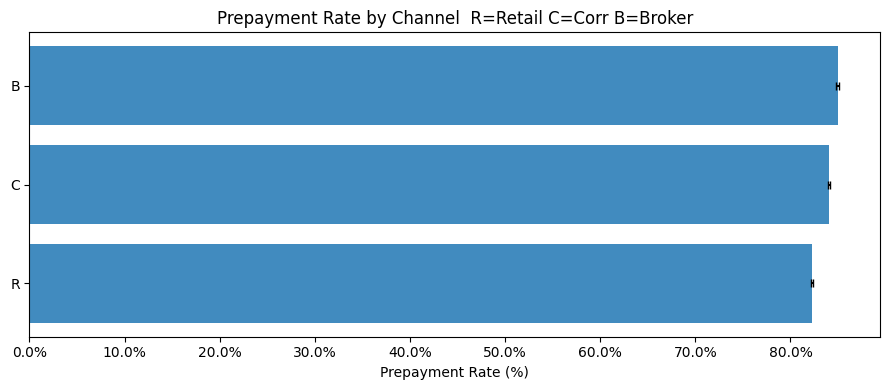

,occupancy_status,n,n_pre,rate_pct
1,I,130322,102687,78.79
2,S,63744,52730,82.72
0,P,1099354,919626,83.65


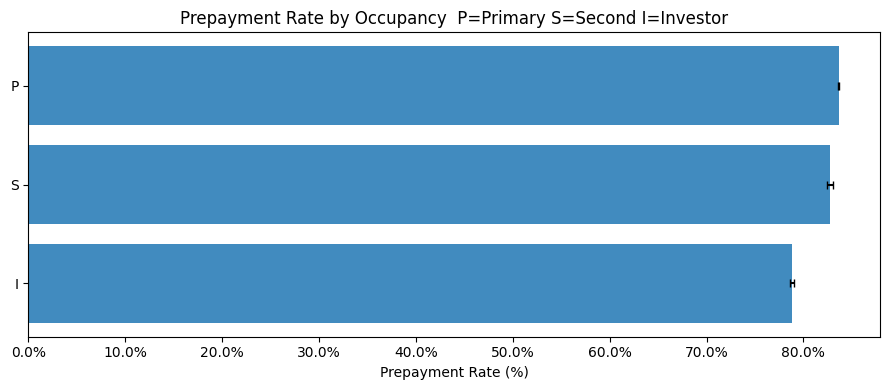

,property_type,n,n_pre,rate_pct
3,MH,8705,6058,69.59
4,CP,6660,4732,71.05
0,SF,793768,646551,81.45
2,CO,128907,109362,84.84
1,PU,355380,308340,86.76


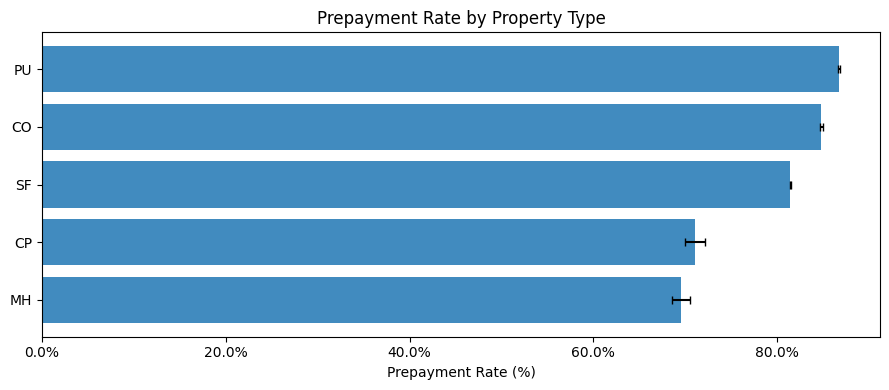

,seasoning_bucket,n,n_pre,rate_pct
2,120m+,233915,22961,9.82
4,0-12m,127210,125622,98.75
0,61-120m,398351,395402,99.26
3,37-60m,187003,185722,99.31
1,13-36m,346941,345336,99.54


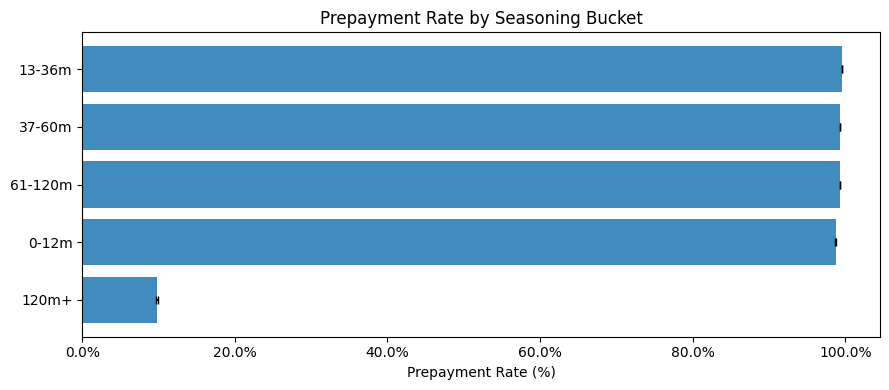

,property_state,n,n_pre,rate_pct
39,PR,5189,1845,35.56
53,GU,38,22,57.89
52,VI,152,99,65.13
5,NY,42400,29375,69.28
49,WV,2787,2050,73.56
30,CT,10962,8291,75.63
9,PA,37303,28318,75.91
26,LA,15992,12178,76.15
37,MS,6340,4837,76.29
36,NM,7715,5978,77.49


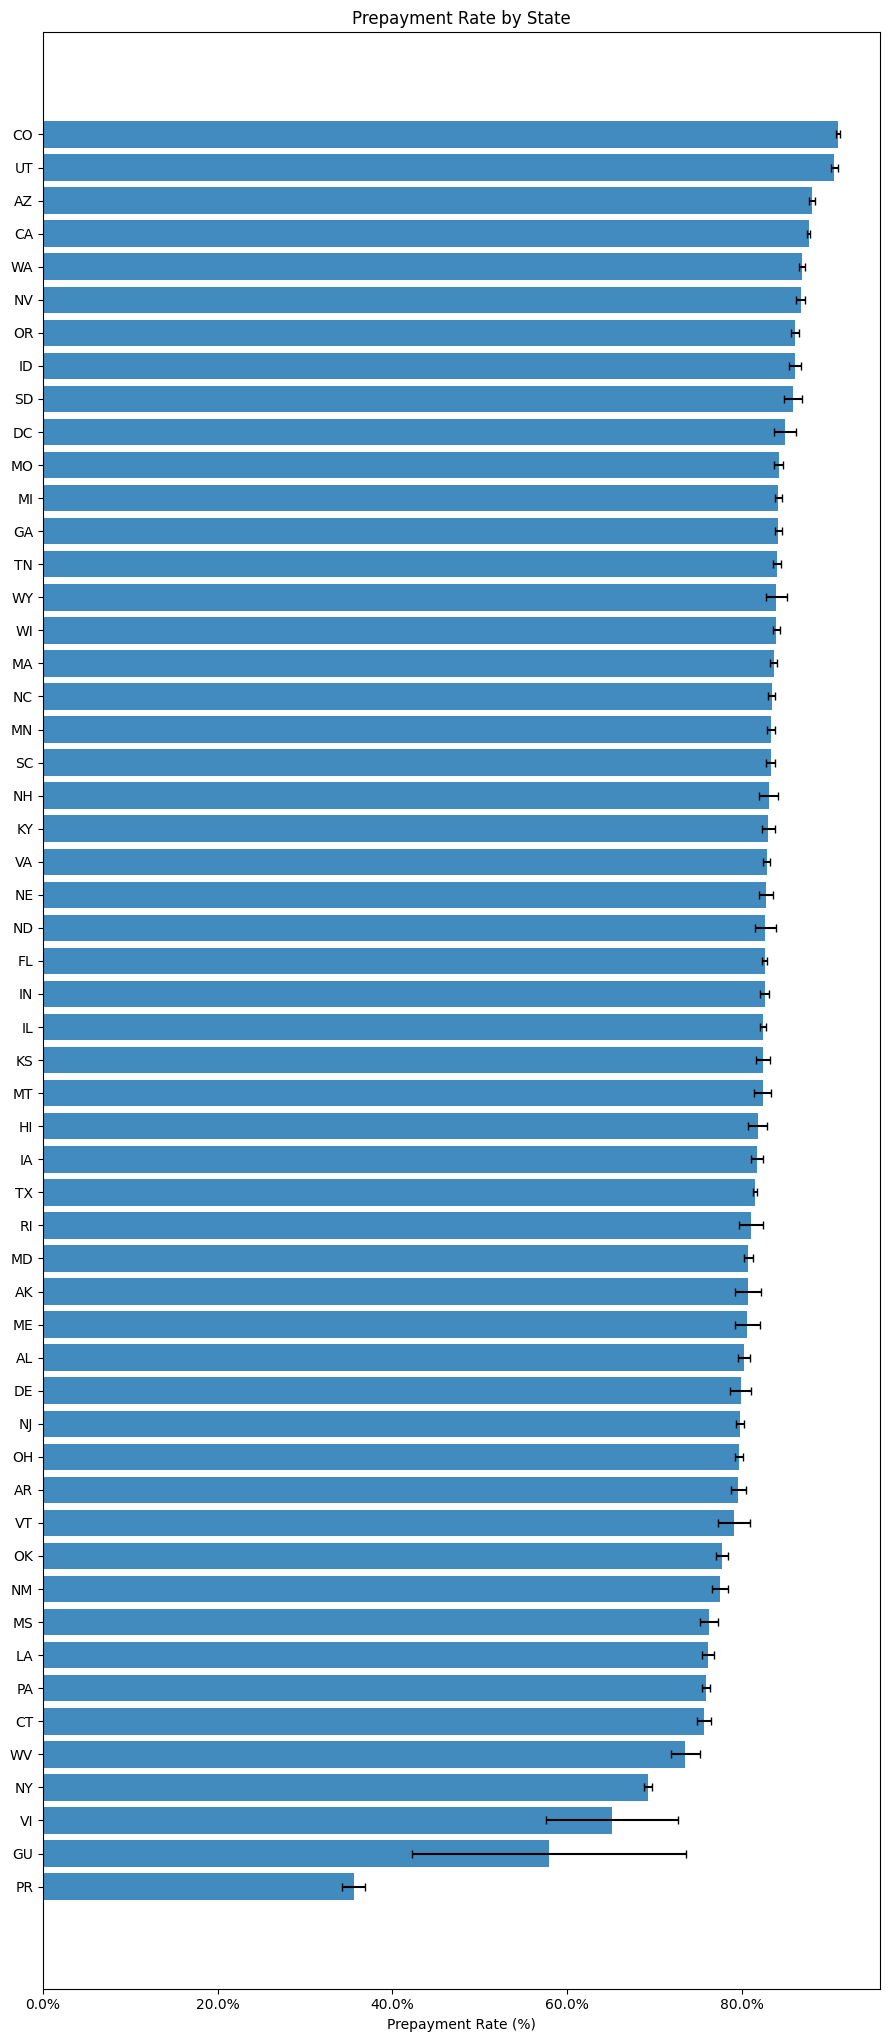

,first_time_homebuyer,n,n_pre,rate_pct
1,Y,289036,238898,82.65
0,N,1004384,836145,83.25


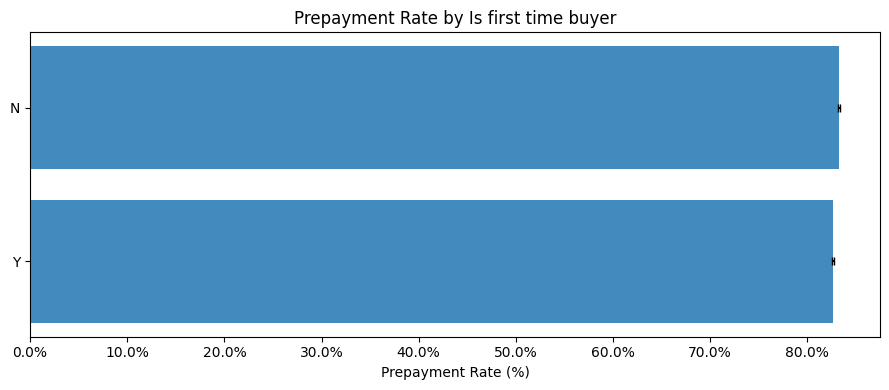

,high_balance_loan,n,n_pre,rate_pct
1,Y,10259,7530,73.40
0,N,1283161,1067513,83.19


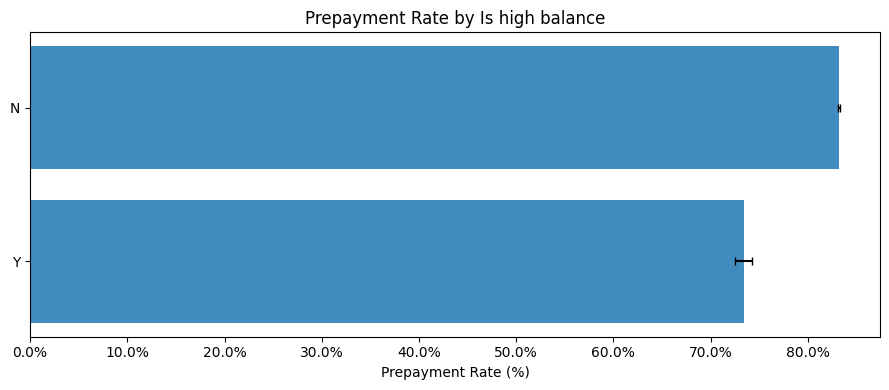

,high_ltv,n,n_pre,rate_pct
0,0,902366,739793,81.98
1,1,391054,335250,85.73


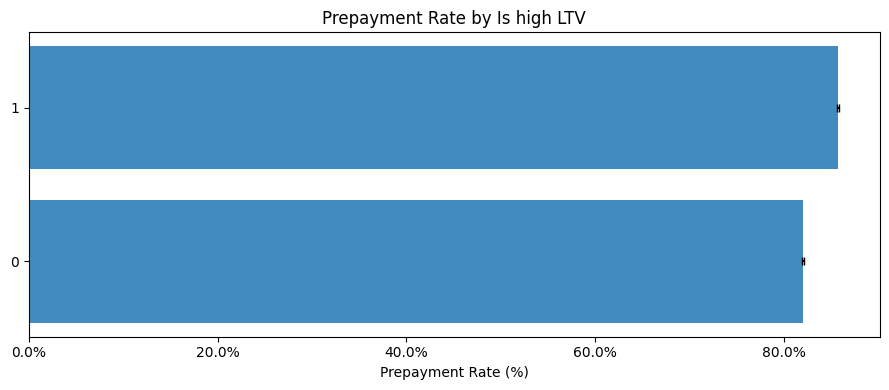

,relocation_mortgage,n,n_pre,rate_pct
0,N,1279631,1062597,83.04
1,Y,13789,12446,90.26


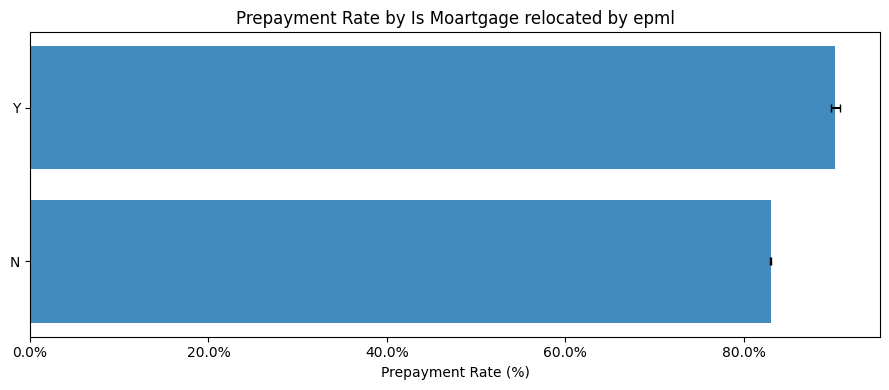

In [45]:
CATS = [
    ("fico_bucket", "FICO Bucket"),
    ("loan_purpose", "Loan Purpose  C=CashOut R=Refi P=Purchase"),
    ("channel", "Channel  R=Retail C=Corr B=Broker"),
    ("occupancy_status", "Occupancy  P=Primary S=Second I=Investor"),
    ("property_type", "Property Type"),
    ("seasoning_bucket", "Seasoning Bucket"),
    ("property_state", "State"),
    ("first_time_homebuyer", "Is first time buyer"),
    ("high_balance_loan", "Is high balance"),
    ("high_ltv", "Is high LTV"),
    ("relocation_mortgage", "Is Moartgage relocated by epml"),
]

for col, label in CATS:
    if col not in abt.columns:
        print(f"Skip: {col} not found in abt")
        continue

    agg = (
        abt.filter(F.col(col).isNotNull())
           .groupBy(col)
           .agg(
               F.count("*").alias("n"),
               F.sum("prepaid").alias("n_pre")
           )
           .withColumn("rate", F.col("n_pre") / F.col("n"))
           .orderBy(F.desc("n"))
           .toPandas()
    )

    if len(agg) == 0:
        print(f"Skip: {col} has no data after filtering")
        continue

    agg = agg.sort_values("rate", ascending=True)

    z = 1.96
    agg["ci"] = z * np.sqrt(
        agg["rate"] * (1 - agg["rate"]) / agg["n"].clip(lower=1)
    )

    display(
        agg[[col, "n", "n_pre", "rate"]]
        .assign(rate=lambda x: (x["rate"] * 100).round(2))
        .rename(columns={"rate": "rate_pct"})
    )

    fig, ax = plt.subplots(figsize=(9, max(4, len(agg) * 0.38)))

    ax.barh(
        agg[col].astype(str),
        agg["rate"] * 100,
        xerr=agg["ci"] * 100,
        alpha=0.85,
        capsize=3
    )

    ax.set_xlabel("Prepayment Rate (%)")
    ax.set_title(f"Prepayment Rate by {label}")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))

    fig.tight_layout()
    plt.show()

## Other charts

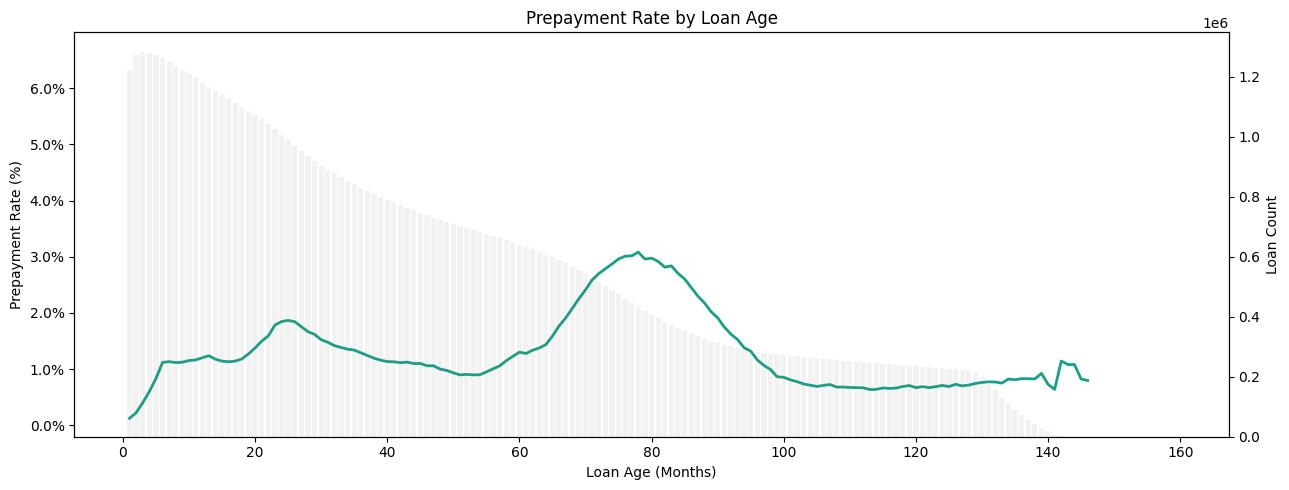

In [13]:
agg = (
    panel.filter(F.col("loan_age").between(1, 360))
         .groupBy("loan_age")
         .agg(
             F.count("*").alias("n"),
             F.sum("prepaid").alias("rate")
         )
         .orderBy("loan_age")
         .toPandas()
)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(
    agg["loan_age"],
    agg["rate"] / agg["n"] * 100,
    color="#16a085",
    linewidth=2
)

ax1.set_xlabel("Loan Age (Months)")
ax1.set_ylabel("Prepayment Rate (%)")
ax1.set_title("Prepayment Rate by Loan Age")
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))

ax2 = ax1.twinx()
ax2.bar(
    agg["loan_age"],
    agg["n"],
    alpha=0.10,
    color="grey",
    width=0.8
)
ax2.set_ylabel("Loan Count")

fig.tight_layout()
plt.show()
plt.close(fig)

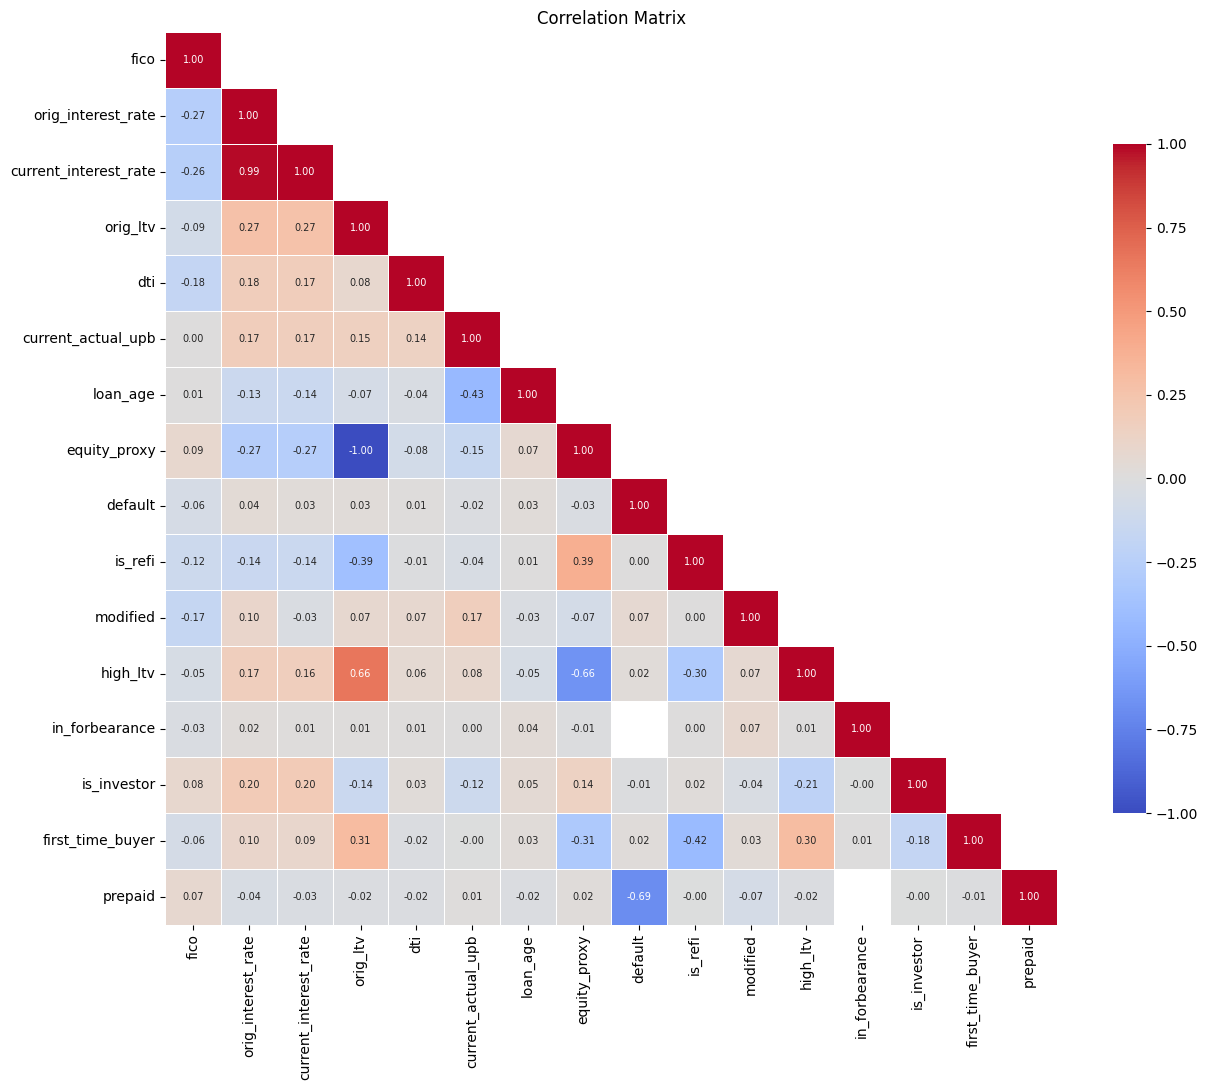

In [19]:
frac = 0.1

cols = (
    [c for c, *_ in NUMERIC_COLS if c in abt.columns] +
    ["default", "is_refi", "modified", "high_ltv",
     "in_forbearance", "is_investor", "first_time_buyer", "prepaid"]
)

cols = [c for c in cols if c in abt.columns]

pdf = (
    abt.select(cols)
       .sample(fraction=frac, seed=42)
       .toPandas()
)

corr = pdf.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 11))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,
    ax=ax,
    linewidths=0.4,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.75}
)

ax.set_title(f"Correlation Matrix")
fig.tight_layout()
plt.show()
plt.close(fig)

,Feature,Column,KS,p_value,n_nonprepaid,n_prepaid
17,total_principal,total_principal,0.428059,5.245327e-98,591,67929
12,coborrower_credit_score_orig,coborrower_credit_score_orig,0.337873,1.592384e-51,503,107935
11,borrower_credit_score_orig,borrower_credit_score_orig,0.337324,1.875886e-166,1647,215375
13,fico,fico,0.337324,1.875886e-166,1647,215375
8,upb_fraction,upb_fraction,0.265881,1.597180e-102,1647,215375
14,delinquency_months,delinquency_months,0.264281,8.474243e-37,594,70542
1,orig_interest_rate,orig_interest_rate,0.221650,4.935325e-71,1647,215375
9,loan_age,loan_age,0.200503,4.336324e-58,1647,215375
6,orig_upb,orig_upb,0.179641,1.233158e-46,1647,215375
0,current_interest_rate,current_interest_rate,0.167076,2.320579e-40,1647,215375


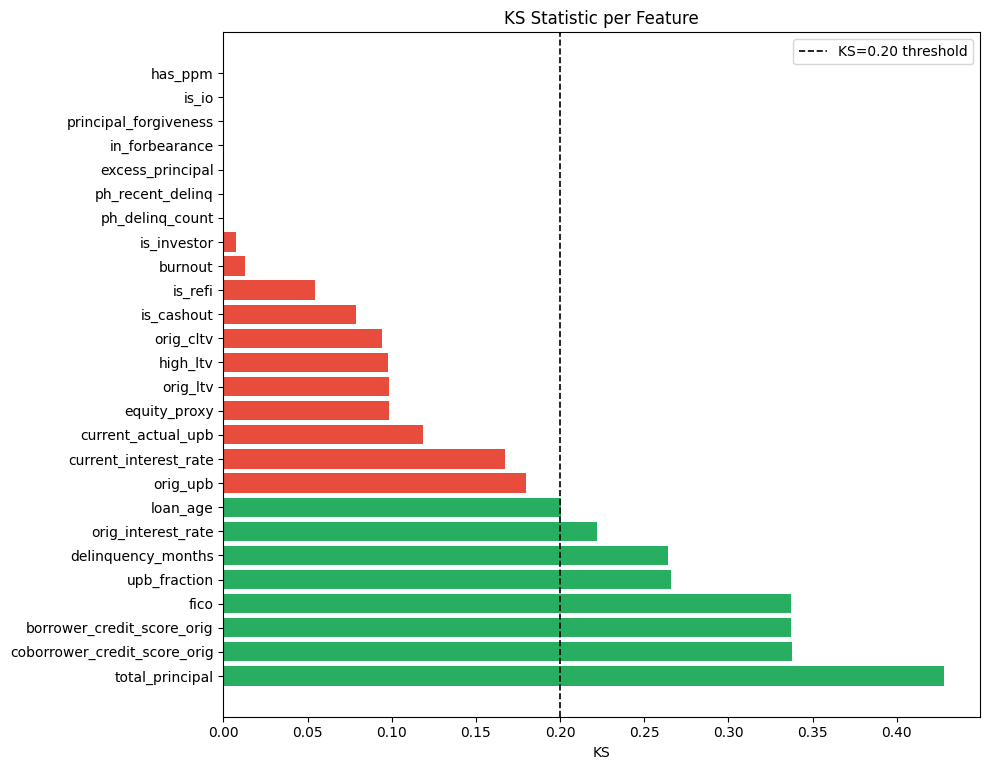

In [27]:
from scipy.stats import ks_2samp
import pandas as pd
import matplotlib.pyplot as plt

frac = 0.2

KS_EXTRA = [
    "current_interest_rate",
    "orig_interest_rate",
    "rate_spread",
    "orig_ltv",
    "orig_cltv",
    "equity_proxy",
    "high_ltv",
    "orig_upb",
    "current_actual_upb",
    "interest_bearing_upb",
    "upb_fraction",
    "loan_age",
    "remaining_months_to_mat",
    "remaining_months_legal_mat",
    "burnout",
    "borrower_credit_score_orig",
    "coborrower_credit_score_orig",
    "orig_classic_fico",
    "current_classic_fico",
    "fico",
    "delinquency_months",
    "ph_delinq_count",
    "ph_recent_delinq",
    "scheduled_principal",
    "unscheduled_principal",
    "total_principal",
    "excess_principal",
    "total_deferral_amount",
    "principal_forgiveness",
    "alt_delinquency_res_count",
    "in_forbearance",
    "has_deferral",
    "modified",
    "is_refi",
    "is_cashout",
    "is_io",
    "has_ppm",
    "is_investor",
]

ks_cols = [c for c in KS_EXTRA if c in abt.columns]

pdf = (
    abt.select(ks_cols + ["prepaid"])
       .sample(fraction=frac, seed=42)
       .toPandas()
)

rows = []

for col in ks_cols:
    g0 = pdf.loc[pdf["prepaid"] == 0, col].dropna().values
    g1 = pdf.loc[pdf["prepaid"] == 1, col].dropna().values

    if len(g0) < 100 or len(g1) < 100:
        continue

    ks, pv = ks_2samp(g0, g1)

    rows.append({
        "Feature": col,
        "Column": col,
        "KS": ks,
        "p_value": pv,
        "n_nonprepaid": len(g0),
        "n_prepaid": len(g1),
    })

ks_df = pd.DataFrame(rows)

if ks_df.empty:
    print("No KS results were produced.")
    print("Possible reasons:")
    print("- sampled dataframe is too small")
    print("- prepaid class has too few observations")
    print("- selected columns are mostly missing")
else:
    ks_df = ks_df.sort_values("KS", ascending=False)
    display(ks_df)

    fig, ax = plt.subplots(figsize=(10, max(5, len(ks_df) * 0.3)))

    colors = [
        "#27ae60" if k > 0.2 else "#e74c3c"
        for k in ks_df["KS"]
    ]

    ax.barh(
        ks_df["Feature"],
        ks_df["KS"],
        color=colors
    )

    ax.axvline(
        0.2,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="KS=0.20 threshold"
    )

    ax.set_title("KS Statistic per Feature")
    ax.set_xlabel("KS")
    ax.legend()

    fig.tight_layout()
    plt.show()
    plt.close(fig)

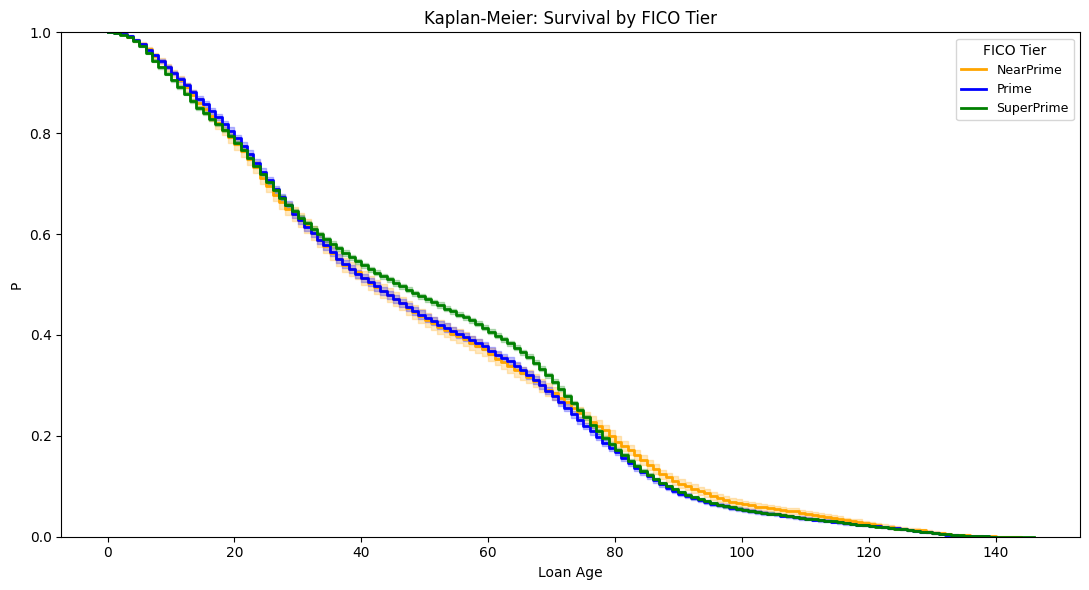

In [39]:
from lifelines import KaplanMeierFitter

frac = 0.05

pdf = (
    abt.select("loan_age", "prepaid", "fico_bucket")
       .filter(
           F.col("loan_age").isNotNull() &
           F.col("prepaid").isNotNull() &
           F.col("fico_bucket").isNotNull()
       )
       .sample(fraction=frac, seed=42)
       .toPandas()
)

pdf["loan_age"] = pd.to_numeric(pdf["loan_age"], errors="coerce")
pdf["prepaid"] = pd.to_numeric(pdf["prepaid"], errors="coerce")

pdf = pdf.dropna(subset=["loan_age", "prepaid", "fico_bucket"])
pdf["prepaid"] = pdf["prepaid"].astype(int)

fig, ax = plt.subplots(figsize=(11, 6))

pal = {
    "SubPrime": "red",
    "NearPrime": "orange",
    "Prime": "blue",
    "SuperPrime": "green"
}

for bucket in ["SubPrime", "NearPrime", "Prime", "SuperPrime"]:
    grp = pdf[pdf["fico_bucket"] == bucket].copy()

    if len(grp) < 50:
        continue

    grp = grp.dropna(subset=["loan_age", "prepaid"])
    grp = grp[(grp["loan_age"] > 0) & (grp["prepaid"].isin([0, 1]))]

    if len(grp) < 50:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=grp["loan_age"].clip(lower=1),
        event_observed=grp["prepaid"],
        label=bucket
    )

    kmf.plot_survival_function(
        ax=ax,
        ci_show=True,
        color=pal[bucket],
        linewidth=2
    )

ax.set_title("Kaplan-Meier: Survival by FICO Tier")
ax.set_xlabel("Loan Age")
ax.set_ylabel("P")
ax.set_ylim(0, 1)
ax.legend(title="FICO Tier", fontsize=9)

fig.tight_layout()
plt.show()
plt.close(fig)

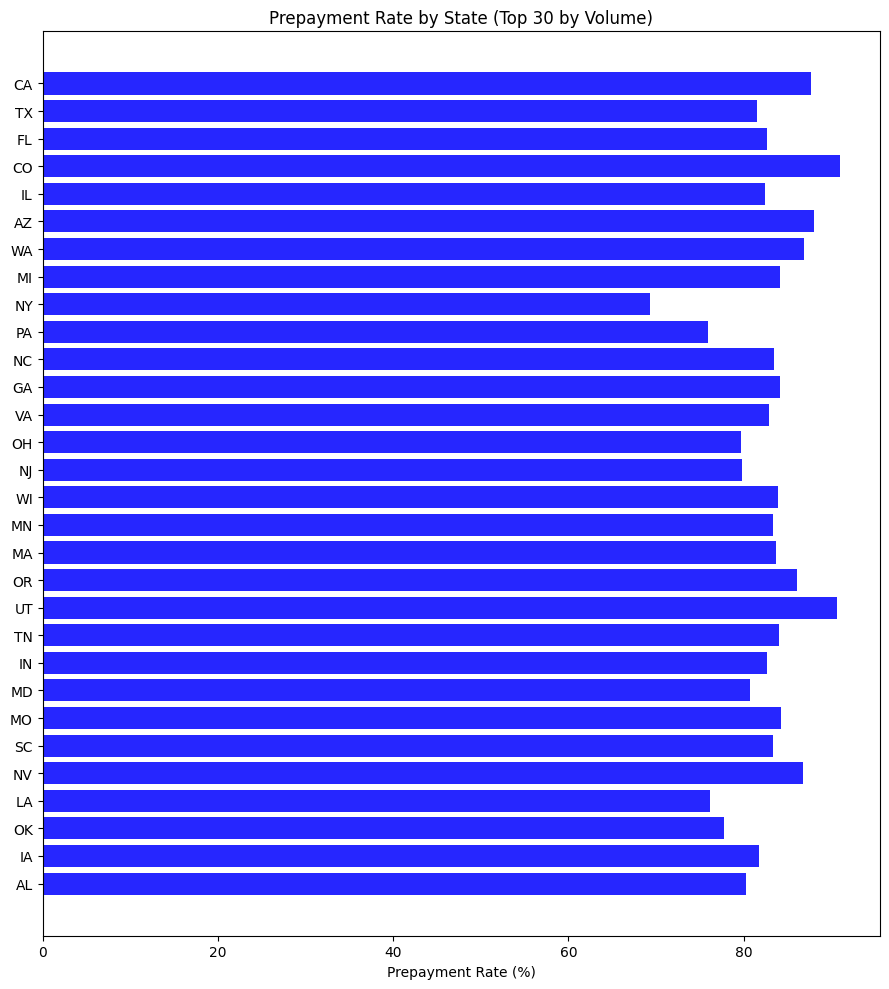

In [42]:
agg = (
    abt.filter(F.col("property_state").isNotNull())
       .groupBy("property_state")
       .agg(
           F.count("*").alias("n"),
           F.sum("prepaid").alias("rate")
       )
       .orderBy(F.desc("n"))
       .toPandas()
)

agg = agg.head(30).sort_values("rate", ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))

ax.barh(
    agg["property_state"],
    agg["rate"] / agg["n"] * 100,
    color="blue",
    alpha=0.85
)

ax.set_xlabel("Prepayment Rate (%)")
ax.set_title("Prepayment Rate by State (Top 30 by Volume)")

fig.tight_layout()
plt.show()
plt.close(fig)